<a href="https://www.kaggle.com/code/usharaopatteti/olist?scriptVersionId=324663447" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv


RFM stands for Recency, Frequency, Monetary. It’s a customer analysis method used in e-commerce and marketing to segment customers by how recently they bought, how often they buy, and how much they spend.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import datetime as datetime
import warnings

warnings.filterwarnings('ignore')

In [3]:
customers=pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv")
orders=pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv")
payments=pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv")
order_item=pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv")
order_reviews=pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv")

In [4]:
def df_info(df):
    info= df.info()
    shape= df.shape
    null=df.isnull().sum()
    table=df.head()
    return info,shape,null,table

In [5]:
df_info(customers)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


(None,
 (99441, 5),
 customer_id                 0
 customer_unique_id          0
 customer_zip_code_prefix    0
 customer_city               0
 customer_state              0
 dtype: int64,
                         customer_id                customer_unique_id  \
 0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
 1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
 2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
 3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
 4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   
 
    customer_zip_code_prefix          customer_city customer_state  
 0                     14409                 franca             SP  
 1                      9790  sao bernardo do campo             SP  
 2                      1151              sao paulo             SP  
 3                      8775        mogi das cruzes             SP  
 4                 

In [6]:
print(customers['customer_id'].nunique())
print(customers['customer_unique_id'].nunique())

99441
96096


In [7]:
df_info(orders)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


(None,
 (99441, 8),
 order_id                            0
 customer_id                         0
 order_status                        0
 order_purchase_timestamp            0
 order_approved_at                 160
 order_delivered_carrier_date     1783
 order_delivered_customer_date    2965
 order_estimated_delivery_date       0
 dtype: int64,
                            order_id                       customer_id  \
 0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
 1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
 2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
 3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
 4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   
 
   order_status order_purchase_timestamp    order_approved_at  \
 0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
 1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
 2    delive

In [8]:
df_info(payments)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


(None,
 (103886, 5),
 order_id                0
 payment_sequential      0
 payment_type            0
 payment_installments    0
 payment_value           0
 dtype: int64,
                            order_id  payment_sequential payment_type  \
 0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
 1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
 2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   
 3  ba78997921bbcdc1373bb41e913ab953                   1  credit_card   
 4  42fdf880ba16b47b59251dd489d4441a                   1  credit_card   
 
    payment_installments  payment_value  
 0                     8          99.33  
 1                     1          24.39  
 2                     1          65.71  
 3                     8         107.78  
 4                     2         128.45  )

In [9]:
df_info(order_item)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


(None,
 (112650, 7),
 order_id               0
 order_item_id          0
 product_id             0
 seller_id              0
 shipping_limit_date    0
 price                  0
 freight_value          0
 dtype: int64,
                            order_id  order_item_id  \
 0  00010242fe8c5a6d1ba2dd792cb16214              1   
 1  00018f77f2f0320c557190d7a144bdd3              1   
 2  000229ec398224ef6ca0657da4fc703e              1   
 3  00024acbcdf0a6daa1e931b038114c75              1   
 4  00042b26cf59d7ce69dfabb4e55b4fd9              1   
 
                          product_id                         seller_id  \
 0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
 1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
 2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
 3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
 4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   
 
    

In [10]:
df_info(order_reviews)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


(None,
 (99224, 7),
 review_id                      0
 order_id                       0
 review_score                   0
 review_comment_title       87656
 review_comment_message     58247
 review_creation_date           0
 review_answer_timestamp        0
 dtype: int64,
                           review_id                          order_id  \
 0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
 1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
 2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   
 3  e64fb393e7b32834bb789ff8bb30750e  658677c97b385a9be170737859d3511b   
 4  f7c4243c7fe1938f181bec41a392bdeb  8e6bfb81e283fa7e4f11123a3fb894f1   
 
    review_score review_comment_title  \
 0             4                  NaN   
 1             5                  NaN   
 2             5                  NaN   
 3             5                  NaN   
 4             5                  NaN   
 
                               re

orders and order_review table has missing values

In [11]:
customers['customer_unique_id'].nunique()

96096

In [12]:
customers['customer_id'].nunique()

99441

In [13]:
customers['customer_unique_id'].value_counts().head(20)

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
ca77025e7201e3b30c44b472ff346268     7
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
f0e310a6839dce9de1638e0fe5ab282a     6
63cfc61cee11cbe306bff5857d00bfe4     6
12f5d6e1cbf93dafd9dcc19095df0b3d     6
de34b16117594161a6a89c50b289d35a     6
47c1a3033b8b77b3ab6e109eb4d5fdf3     6
dc813062e0fc23409cd255f7f53c7074     6
b4e4f24de1e8725b74e4a1f4975116ed     5
35ecdf6858edc6427223b64804cf028e     5
fe81bb32c243a86b2f86fbf053fe6140     5
56c8638e7c058b98aae6d74d2dd6ea23     5
5e8f38a9a1c023f3db718edcf926a2db     5
74cb1ad7e6d5674325c1f99b5ea30d82     5
4e65032f1f574189fb793bac5a867bbc     5
394ac4de8f3acb14253c177f0e15bc58     5
b39dde6dd619943190a8cc9aa6db38a4     4
Name: count, dtype: int64

In [14]:
payments['order_id'].duplicated().sum()

np.int64(4446)

olist_order_payments_dataset.csv can have multiple payment rows per order, and olist_order_items_dataset.csv can also have multiple item rows per order. That means a straight merge on order_id can create repeated rows and inflate totals if you treat every row as a separate order.

In [15]:
# one row per order
payments_order = payments.groupby('order_id', as_index=False)['payment_value'].sum()

# one row per customer-order
order_base = orders[['order_id', 'customer_id', 'order_purchase_timestamp', 'order_status']]

In [16]:
master = customers.merge(order_base, on='customer_id', how='inner')
master_df = master.merge(payments_order, on='order_id', how='inner')

In [17]:
master_df['order_id'].duplicated().sum()

np.int64(0)

In [18]:
master_df

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_purchase_timestamp,order_status,payment_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,2017-05-16 15:05:35,delivered,146.87
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,2018-01-12 20:48:24,delivered,335.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,2018-05-19 16:07:45,delivered,157.73
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,2018-03-13 16:06:38,delivered,173.30
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,2018-07-29 09:51:30,delivered,252.25
...,...,...,...,...,...,...,...,...,...
99435,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,2018-04-07 15:48:17,delivered,88.78
99436,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,2018-04-04 08:20:22,delivered,129.06
99437,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,2018-04-08 20:11:50,delivered,56.04
99438,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,2017-11-03 21:08:33,delivered,711.07


In [19]:
master_df['order_status'].value_counts()

order_status
delivered      96477
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

we are selecting only delivered items

In [20]:
#filtered with delivered status
master_df=master_df[master_df['order_status'] == 'delivered']

## EDA

* Fix your datetime columns first
* Plot monthly revenue trend — prove the business problem
* New vs returning customers — split the revenue
* Top 20% customers — how much revenue do they drive?
* Order value distribution — understand your typical customer


In [21]:
master_df['order_purchase_timestamp']=pd.to_datetime(master_df['order_purchase_timestamp'])

In [22]:
master_df['order_dayofweek']=master_df['order_purchase_timestamp'].dt.day_name()
master_df['order_month']=master_df['order_purchase_timestamp'].dt.to_period("M")
master_df['order_year']=master_df['order_purchase_timestamp'].dt.to_period("Y")

In [23]:
master_df['order_dayofweek'].value_counts()

order_dayofweek
Monday       15701
Tuesday      15503
Wednesday    15076
Thursday     14322
Friday       13685
Sunday       11635
Saturday     10555
Name: count, dtype: int64

In [24]:
monthly_revenue=master_df.groupby('order_month')['payment_value'].sum().reset_index()
monthly_revenue['order_month']=monthly_revenue['order_month'].astype(str)

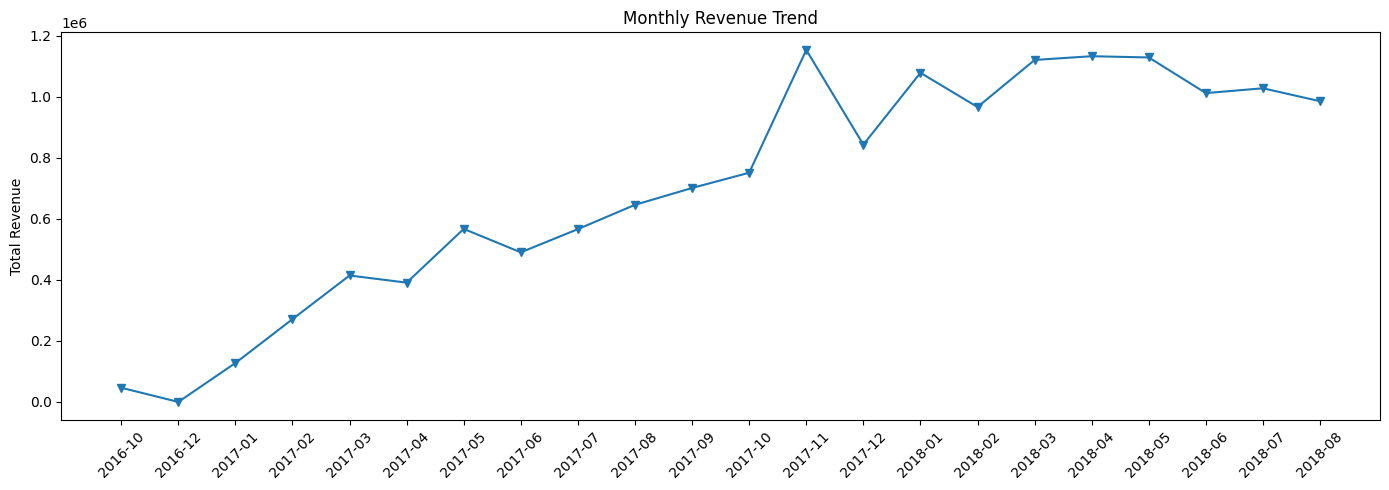

In [25]:
plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['order_month'],monthly_revenue['payment_value'],marker='v')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

In [26]:
order_counts = master_df.groupby('customer_unique_id')['order_id'].count().reset_index()
order_counts.columns = ['customer_unique_id', 'total_orders']


In [27]:
order_counts['customer_type']=order_counts['total_orders'].apply(lambda x: 'Returning' if x>1 else'New')


In [28]:
print(order_counts['customer_type'].value_counts())
print(order_counts['customer_type'].value_counts(normalize=True)*100)

customer_type
New          90556
Returning     2801
Name: count, dtype: int64
customer_type
New          96.999689
Returning     3.000311
Name: proportion, dtype: float64


In [29]:
customer_revenue=master_df.groupby("customer_unique_id")['payment_value'].sum().reset_index()
customer_revenue=customer_revenue.sort_values('payment_value',ascending=False)

In [30]:
top_20_cutoff=int(len(customer_revenue)*0.2)
top_20_revenue=customer_revenue.iloc[:top_20_cutoff]['payment_value'].sum()
total_revenue=customer_revenue['payment_value'].sum()

print(f"Top 20% customers drive: {top_20_revenue/total_revenue*100:.1f}% of revenue")

Top 20% customers drive: 53.5% of revenue


In [31]:
print(master_df.shape)
print(master_df['order_status'].value_counts())

(96477, 12)
order_status
delivered    96477
Name: count, dtype: int64


In [32]:
dupe_check = master_df['order_id'].duplicated().sum()
print(f"Duplicate order_ids: {dupe_check}")

Duplicate order_ids: 0


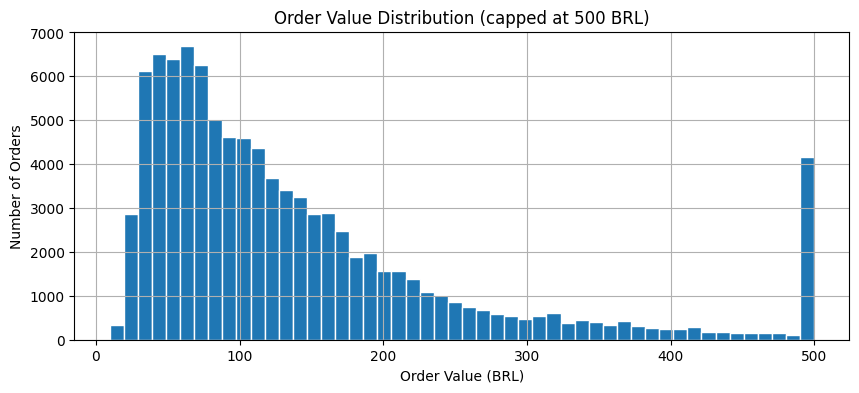

count    96477.000000
mean       159.856357
std        218.813144
min          9.590000
25%         61.880000
50%        105.280000
75%        176.330000
max      13664.080000
Name: payment_value, dtype: float64


In [33]:
# Distribution of order values
plt.figure(figsize=(10, 4))
master_df['payment_value'].clip(upper=500).hist(bins=50, edgecolor='white')
plt.title('Order Value Distribution (capped at 500 BRL)')
plt.xlabel('Order Value (BRL)')
plt.ylabel('Number of Orders')
plt.show()

# Summary stats
print(master_df['payment_value'].describe())

In [34]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96477 entries, 0 to 99439
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   customer_id               96477 non-null  object        
 1   customer_unique_id        96477 non-null  object        
 2   customer_zip_code_prefix  96477 non-null  int64         
 3   customer_city             96477 non-null  object        
 4   customer_state            96477 non-null  object        
 5   order_id                  96477 non-null  object        
 6   order_purchase_timestamp  96477 non-null  datetime64[ns]
 7   order_status              96477 non-null  object        
 8   payment_value             96477 non-null  float64       
 9   order_dayofweek           96477 non-null  object        
 10  order_month               96477 non-null  period[M]     
 11  order_year                96477 non-null  period[Y-DEC] 
dtypes: datetime64[ns](1), f

In [35]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96477 entries, 0 to 99439
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   customer_id               96477 non-null  object        
 1   customer_unique_id        96477 non-null  object        
 2   customer_zip_code_prefix  96477 non-null  int64         
 3   customer_city             96477 non-null  object        
 4   customer_state            96477 non-null  object        
 5   order_id                  96477 non-null  object        
 6   order_purchase_timestamp  96477 non-null  datetime64[ns]
 7   order_status              96477 non-null  object        
 8   payment_value             96477 non-null  float64       
 9   order_dayofweek           96477 non-null  object        
 10  order_month               96477 non-null  period[M]     
 11  order_year                96477 non-null  period[Y-DEC] 
dtypes: datetime64[ns](1), f

## RFM-Recency,Frequency and Monetary 

In [36]:
reference_date=master_df['order_purchase_timestamp'].max()+pd.Timedelta(days=1)
reference_date

Timestamp('2018-08-30 15:00:37')

In [37]:
rfm=master_df.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (reference_date-x.max()).days),
    Frequency=('order_id','count'),
    Monetary=('payment_value','sum')    
).reset_index()

In [38]:
print(rfm.shape)
print(rfm.head())
print(rfm.describe())

(93357, 4)
                 customer_unique_id  Recency  Frequency  Monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19
2  0000f46a3911fa3c0805444483337064      537          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89
            Recency     Frequency      Monetary
count  93357.000000  93357.000000  93357.000000
mean     237.936673      1.033420    165.198772
std      152.584315      0.209099    226.314579
min        1.000000      1.000000      9.590000
25%      114.000000      1.000000     63.060000
50%      219.000000      1.000000    107.780000
75%      346.000000      1.000000    182.560000
max      695.000000     15.000000  13664.080000


In [39]:
rfm['r_score'] = pd.qcut(rfm['Recency'], q=5,labels=[5, 4, 3, 2, 1]).astype('int')
rfm['f_score']=pd.qcut(rfm['Frequency'].rank(method='first'),q=5,labels=[1,2,3,4,5]).astype(int)
rfm['m_score']=pd.qcut(rfm['Monetary'].rank(method='first'),q=5,labels=[1,2,3,4,5]).astype(int)

In [40]:
rfm['RFM_score'] = (rfm['r_score'].astype(str) +
                  rfm['f_score'].astype(str) +
                  rfm['m_score'].astype(str))

In [41]:
print(rfm[['customer_unique_id', 'Recency', 'Frequency','Monetary', 'r_score', 'f_score', 'm_score', 'RFM_score']].head(10))

                 customer_unique_id  Recency  Frequency  Monetary  r_score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90        4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19        4   
2  0000f46a3911fa3c0805444483337064      537          1     86.22        1   
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62        2   
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89        2   
5  0004bd2a26a76fe21f786e4fbd80607f      146          1    166.98        4   
6  00050ab1314c0e55a6ca13cf7181fecf      132          1     35.38        4   
7  00053a61a98854899e70ed204dd4bafe      183          1    419.18        3   
8  0005e1862207bf6ccc02e4228effd9a0      543          1    150.12        1   
9  0005ef4cd20d2893f0d9fbd94d3c0d97      170          1    129.76        4   

   f_score  m_score RFM_score  
0        1        4       414  
1        1        1       411  
2        1        2       112  
3        1   

In [42]:
def assign_segment(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Promising'
    elif r >= 3 and f <= 2 and m <= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Dormant'
    elif r == 1 and f == 1:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# See segment distribution
print(rfm['Segment'].value_counts())
print(rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False))


Segment
Needs Attention        32939
Promising              14984
Loyal Customers        14217
At Risk                13166
Champions               6493
Dormant                 6315
Potential Loyalists     3021
Lost                    2222
Name: count, dtype: int64
Segment
Needs Attention        3753684.84
At Risk                3206071.57
Loyal Customers        2944014.36
Promising              2448804.73
Champions              2026656.84
Lost                    526594.48
Dormant                 352568.09
Potential Loyalists     164066.86
Name: Monetary, dtype: float64


### BRL 4M in revenue is actively at risk of being lost forever


At Risk (BRL 3.2M) + Dormant (BRL 353K) + Lost (BRL 527K) = 26.5% of total revenue sitting in churned or churning customers. This answers the original business question: the company isn't losing revenue because of bad marketing — it's losing existing customers and nobody is trying to keep them.

### "Needs Attention" is your biggest segment — and nobody knows who they are


32,939 customers, BRL 3.75M revenue — the single largest segment by both count and revenue — and they fall into no clear category. These are mixed-signal customers. This is not a failure of your segmentation. This is a real business problem: these customers have unclear intent and are being ignored entirely.

### Champions are only 6,493 customers but drive BRL 2M — protect them first


Champions represent just 6.9% of customers but 13.4% of revenue. More importantly, they buy recently, buy often, and spend most. If even 20% of them downgrade to "Loyal" due to neglect, that's BRL 400K at risk. The business should be actively rewarding these people — they currently get the same treatment as everyone else.

### Promising + Potential Loyalists = 18,005 customers who could become Loyal


These customers bought recently but not frequently. They haven't decided yet whether to come back. A targeted second-purchase incentive to this group — before they go cold — is the highest ROI action available. Converting even 10% to repeat buyers adds meaningful revenue without any new acquisition cost.

In [43]:
total_rev = rfm['Monetary'].sum()

# Revenue at risk = At Risk + Dormant + Lost
risk_segments = ['At Risk', 'Dormant', 'Lost']
rev_at_risk = rfm[rfm['Segment'].isin(risk_segments)]['Monetary'].sum()
customers_at_risk = rfm[rfm['Segment'].isin(risk_segments)].shape[0]

print(f"Total revenue: BRL {total_rev:,.0f}")
print(f"Revenue at risk: BRL {rev_at_risk:,.0f}")
print(f"% of revenue at risk: {rev_at_risk/total_rev*100:.1f}%")
print(f"Customers at risk: {customers_at_risk:,}")

# Average revenue per at-risk customer
avg_risk = rev_at_risk / customers_at_risk
print(f"Avg revenue per at-risk customer: BRL {avg_risk:,.0f}")

Total revenue: BRL 15,422,462
Revenue at risk: BRL 4,085,234
% of revenue at risk: 26.5%
Customers at risk: 21,703
Avg revenue per at-risk customer: BRL 188


"While **26.5%** of revenue — **BRL 4.08M** — sits in confirmed at-risk segments, an additional BRL **3.75M** belongs to **32,939** customers with unclear intent. Together, these two groups represent over **BRL 7.8M**, or **50.6%** of total revenue, with no active retention strategy."

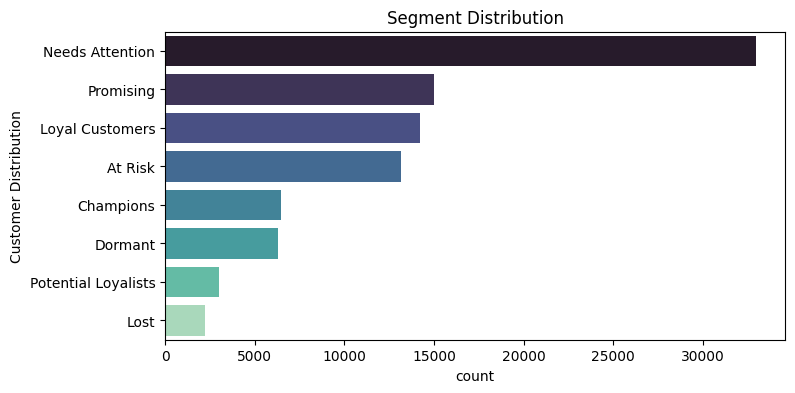

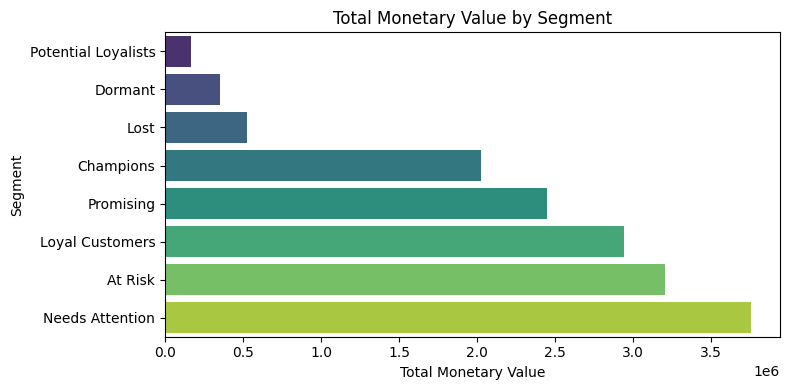

In [44]:
plt.figure(figsize=(8,4))
sns.barplot(x=rfm['Segment'].value_counts(),y=rfm['Segment'].value_counts().keys(),palette='mako')
plt.ylabel('Customer Distribution')
plt.title("Segment Distribution")
plt.show()

segment_rev = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=True)
plt.figure(figsize=(8,4))
sns.barplot(x=segment_rev.values, y=segment_rev.index, palette='viridis')
plt.xlabel('Total Monetary Value')
plt.ylabel('Segment')
plt.title('Total Monetary Value by Segment')
plt.tight_layout()
plt.show()


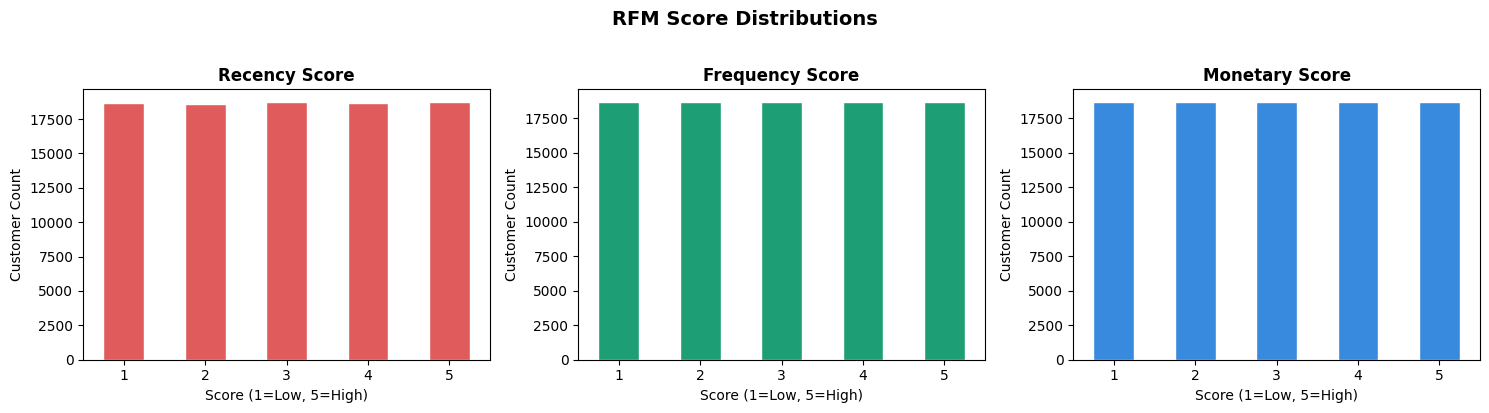

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color, title in zip(
    axes,
    ['r_score', 'f_score', 'm_score'],
    ['#E05C5C', '#1D9E75', '#378ADD'],
    ['Recency Score', 'Frequency Score', 'Monetary Score']
):
    rfm[col].value_counts().sort_index().plot(kind='bar', ax=ax, color=color, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Score (1=Low, 5=High)')
    ax.set_ylabel('Customer Count')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('RFM Score Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## K-Means

In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Select and scale RFM features
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']].copy()
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

print("Scaled. Mean should be ~0, std ~1:")
import pandas as pd
print(pd.DataFrame(rfm_scaled, columns=['R','F','M']).describe().round(2))

Scaled. Mean should be ~0, std ~1:
              R         F         M
count  93357.00  93357.00  93357.00
mean       0.00     -0.00     -0.00
std        1.00      1.00      1.00
min       -1.55     -0.16     -0.69
25%       -0.81     -0.16     -0.45
50%       -0.12     -0.16     -0.25
75%        0.71     -0.16      0.08
max        3.00     66.79     59.65


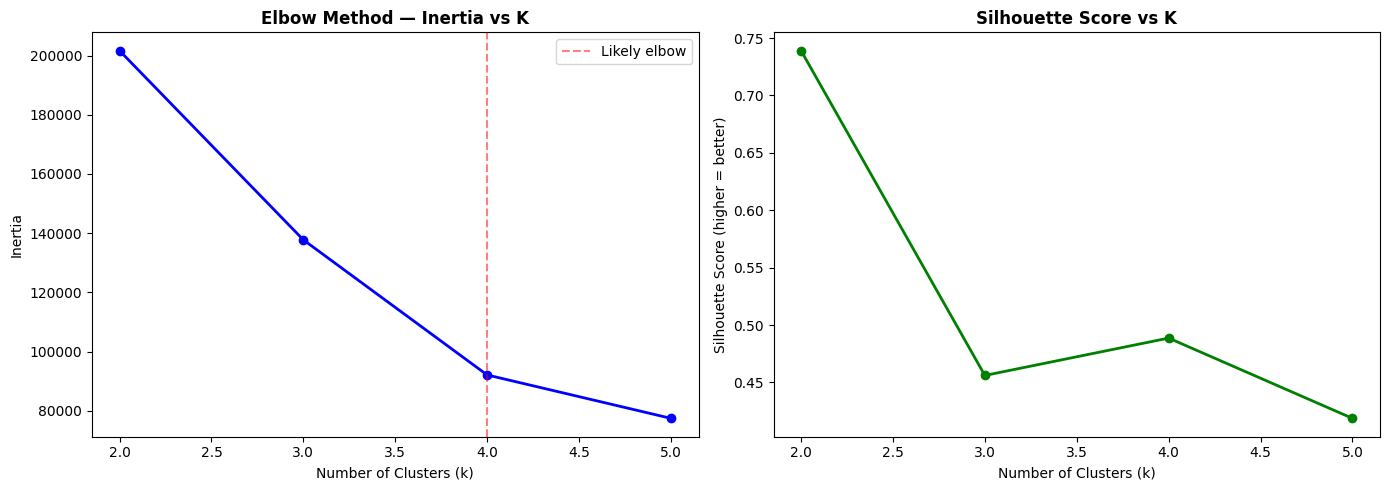

In [47]:
inertias = []
silhouette_scores = []
k_range = range(2, 6)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, km.labels_))

# Plot both side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, 'bo-', linewidth=2)
ax1.set_title('Elbow Method — Inertia vs K', fontweight='bold')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.axvline(x=4, color='red', linestyle='--', alpha=0.5, label='Likely elbow')
ax1.legend()

ax2.plot(k_range, silhouette_scores, 'go-', linewidth=2)
ax2.set_title('Silhouette Score vs K', fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score (higher = better)')

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()


In [48]:
# Print silhouette scores to help decide
for k, s in zip(k_range, silhouette_scores):
    print(f"k={k}: silhouette={s:.4f}")

k=2: silhouette=0.7389
k=3: silhouette=0.4561
k=4: silhouette=0.4886
k=5: silhouette=0.4187


In [49]:
# Fit K-Means with k=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

# Check cluster sizes immediately
print(rfm['Cluster'].value_counts().sort_index())

Cluster
0    50643
1    37526
2     2772
3     2416
Name: count, dtype: int64


In [50]:
# Mean RFM values per cluster
cluster_profile = rfm.groupby('Cluster').agg(
    Recency_mean=('Recency', 'mean'),
    Frequency_mean=('Frequency', 'mean'),
    Monetary_mean=('Monetary', 'mean'),
    Monetary_total=('Monetary', 'sum'),
    Customer_count=('customer_unique_id', 'count')
).round(1)

print(cluster_profile)

# Revenue share per cluster
cluster_profile['Revenue_pct'] = (cluster_profile['Monetary_total'] /
    cluster_profile['Monetary_total'].sum() * 100).round(1)
print(cluster_profile[['Customer_count', 'Revenue_pct']])

         Recency_mean  Frequency_mean  Monetary_mean  Monetary_total  \
Cluster                                                                
0               128.1             1.0          134.4       6805253.1   
1               387.4             1.0          133.5       5008451.5   
2               220.4             2.1          289.7        802993.7   
3               239.5             1.0         1161.3       2805763.5   

         Customer_count  
Cluster                  
0                 50643  
1                 37526  
2                  2772  
3                  2416  
         Customer_count  Revenue_pct
Cluster                             
0                 50643         44.1
1                 37526         32.5
2                  2772          5.2
3                  2416         18.2


In [51]:
# After reading cluster_profile, map numbers to names
# Your mapping will depend on what you see — use the guide below
# Example (your numbers may differ):
cluster_labels = {
    0: 'High Value', # low recency, high F, high M
    1: 'Promising', # low recency, low F, mid M
    2: 'At Risk', # high recency, mid F, mid M
    3: 'Dormant' # high recency, low F, low M
}

# Apply label — READ YOUR PROFILE FIRST before using this mapping
rfm['Cluster_Label'] = rfm['Cluster'].map(cluster_labels)

# Verify — counts should match cluster_profile
print(rfm['Cluster_Label'].value_counts())

Cluster_Label
High Value    50643
Promising     37526
At Risk        2772
Dormant        2416
Name: count, dtype: int64


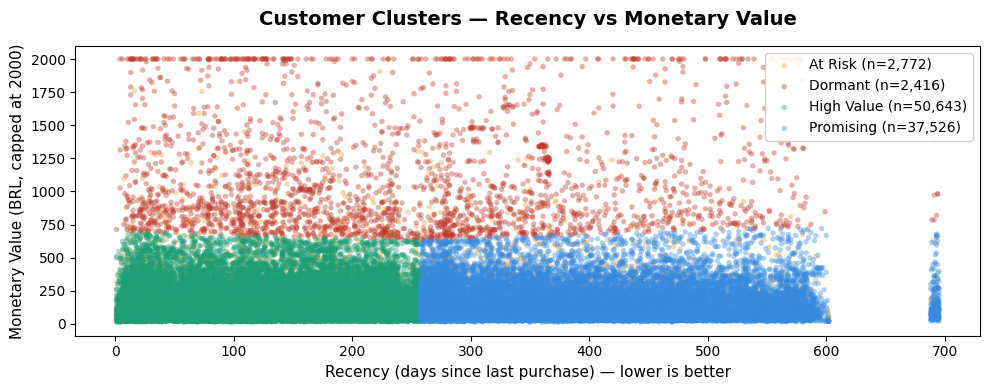

Insight: Clusters show clear separation on Recency axis — confirms K-Means found meaningful structure.


In [89]:
import numpy as np

cluster_colors = {
    'High Value': '#1D9E75',
    'Promising': '#378ADD',
    'At Risk': '#E8A33A',
    'Dormant': '#C0392B'
}

fig, ax = plt.subplots(figsize=(10, 4))

for label, group in rfm.groupby('Cluster_Label'):
    ax.scatter(
        group['Recency'],
        group['Monetary'].clip(upper=2000), # cap outliers for visibility
        c=cluster_colors[label],
        label=f'{label} (n={len(group):,})',
        alpha=0.4, s=15, edgecolors='none'
    )

ax.set_title('Customer Clusters — Recency vs Monetary Value',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Recency (days since last purchase) — lower is better', fontsize=11)
ax.set_ylabel('Monetary Value (BRL, capped at 2000)', fontsize=11)
ax.legend(fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.savefig('cluster_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Clusters show clear separation on Recency axis — confirms K-Means found meaningful structure.")

Cluster_Label        At Risk  Dormant  High Value  Promising
Segment                                                     
At Risk                 0.07     0.05        0.00       0.89
Champions               0.15     0.06        0.79       0.00
Dormant                 0.00     0.00        0.00       1.00
Lost                    0.00     0.04        0.00       0.96
Loyal Customers         0.05     0.03        0.86       0.06
Needs Attention         0.01     0.02        0.49       0.49
Potential Loyalists     0.00     0.00        0.88       0.12
Promising               0.00     0.03        0.97       0.00


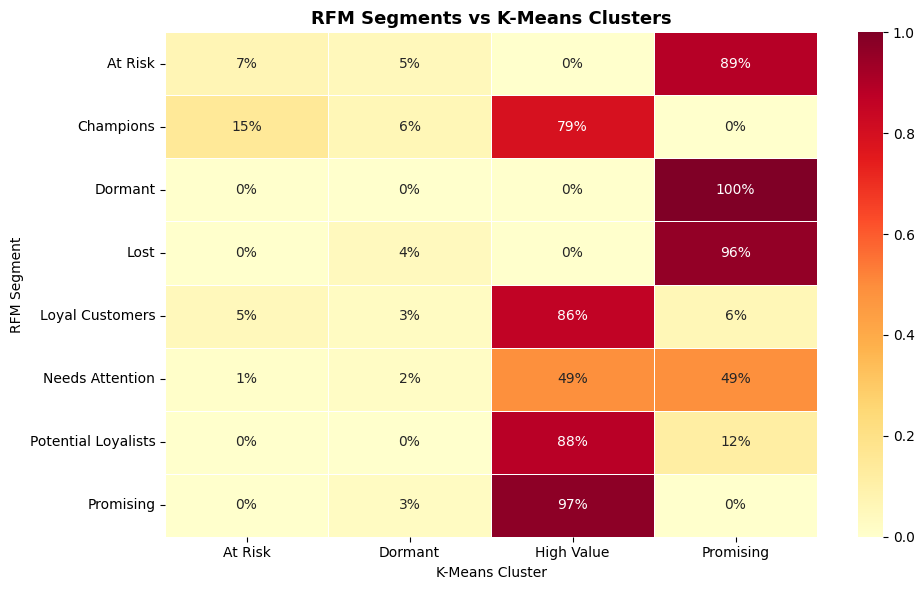

In [53]:
# RFM segment vs K-Means cluster
crosstab = pd.crosstab(
    rfm['Segment'],
    rfm['Cluster_Label'],
    normalize='index' # shows % of each RFM segment in each cluster
).round(2)

print(crosstab)

import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(crosstab, annot=True, fmt='.0%', cmap='YlOrRd',linewidths=0.5, ax=ax)
ax.set_title('RFM Segments vs K-Means Clusters',fontsize=13, fontweight='bold')
ax.set_xlabel('K-Means Cluster')
ax.set_ylabel('RFM Segment')
plt.tight_layout()
plt.show()

## Product category revenue breakdown

In [54]:
product=pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv")
category_translation = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv')
order_items=pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv")

In [55]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [56]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [57]:
print("Product",product.shape)
print("category_translation",category_translation.shape)
print("order_items",order_items.shape)

Product (32951, 9)
category_translation (71, 2)
order_items (112650, 7)


In [58]:
print("Product",product.duplicated('product_id').sum())
print("category_translation",category_translation.duplicated('product_category_name').sum())
print("order_items",order_items.duplicated('order_id').sum())

Product 0
category_translation 0
order_items 13984


In [59]:
print('Null categories:', product['product_category_name'].isnull().sum())

Null categories: 610


we do left join because the null values are left out when using inner join

In [60]:
prod=product.merge(category_translation ,on='product_category_name',how='left')
prods=order_items.merge(prod[['product_id','product_category_name_english']],on='product_id',how='left')

master=master_df[['order_id', 'payment_value', 'customer_state']].drop_duplicates()
category_df=master.merge(prods[['product_id','product_category_name_english','order_id','price','freight_value']], on='order_id',how='inner')

In [61]:
print(category_df.shape)
print(category_df.isnull().sum())

(110194, 7)
order_id                            0
payment_value                       0
customer_state                      0
product_id                          0
product_category_name_english    1559
price                               0
freight_value                       0
dtype: int64


there are null values, we'll uncategorize them

In [62]:
category_df['product_category_name_english']=category_df['product_category_name_english'].fillna('uncategorised')

In [63]:
category_df.groupby('product_category_name_english')['payment_value'].sum().sort_values(ascending=False)

product_category_name_english
bed_bath_table               1692714.28
health_beauty                1620684.04
computers_accessories        1549372.59
furniture_decor              1394466.93
watches_gifts                1387362.45
                                ...    
flowers                         2213.01
home_comfort_2                  1710.54
cds_dvds_musicals               1199.43
fashion_childrens_clothes        718.98
security_and_services            324.51
Name: payment_value, Length: 72, dtype: float64

In [64]:
cat_df=category_df.groupby('product_category_name_english').agg(
    total_revenue=("payment_value","sum"),
    order_count=('order_id',"nunique"),
    avg_order_value=('payment_value',"mean")
).reset_index()

cat_df['revenue_pct'] = (
    cat_df['total_revenue'] / cat_df['total_revenue'].sum() * 100
).round(1)
top10=cat_df.sort_values(by='total_revenue',ascending=False).head(10)
top10

,product_category_name_english,total_revenue,order_count,avg_order_value,revenue_pct
7,bed_bath_table,1692714.28,9272,154.543438,8.6
43,health_beauty,1620684.04,8646,171.283454,8.2
15,computers_accessories,1549372.59,6530,202.691338,7.8
39,furniture_decor,1394466.93,6307,170.890555,7.1
71,watches_gifts,1387362.45,5495,236.791679,7.0
65,sports_leisure,1349446.93,7530,160.057755,6.8
49,housewares,1069787.97,5743,157.437523,5.4
5,auto,833745.67,3810,201.387843,4.2
42,garden_tools,810614.93,3448,189.928522,4.1
20,cool_stuff,744649.32,3559,200.282227,3.8


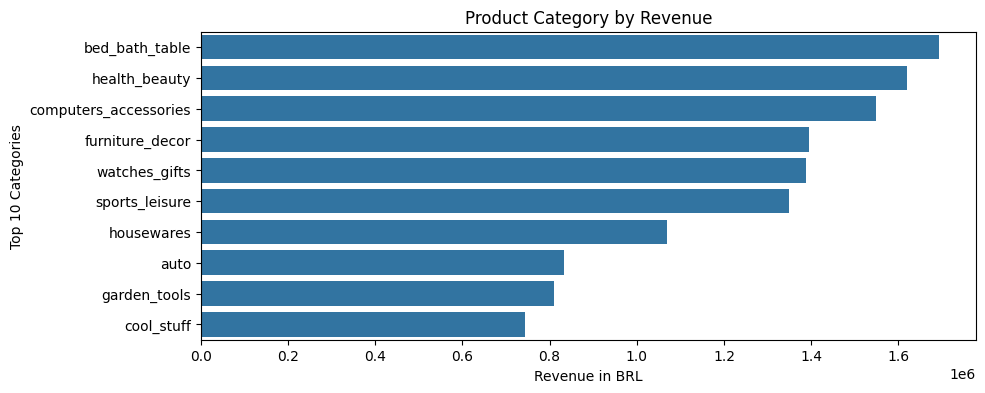

In [65]:
import seaborn as sns
plt.figure(figsize=(10,4))
sns.barplot(x=top10['total_revenue'],y=top10['product_category_name_english'])
plt.title("Product Category by Revenue")
plt.xlabel("Revenue in BRL")
plt.ylabel("Top 10 Categories")
plt.show()


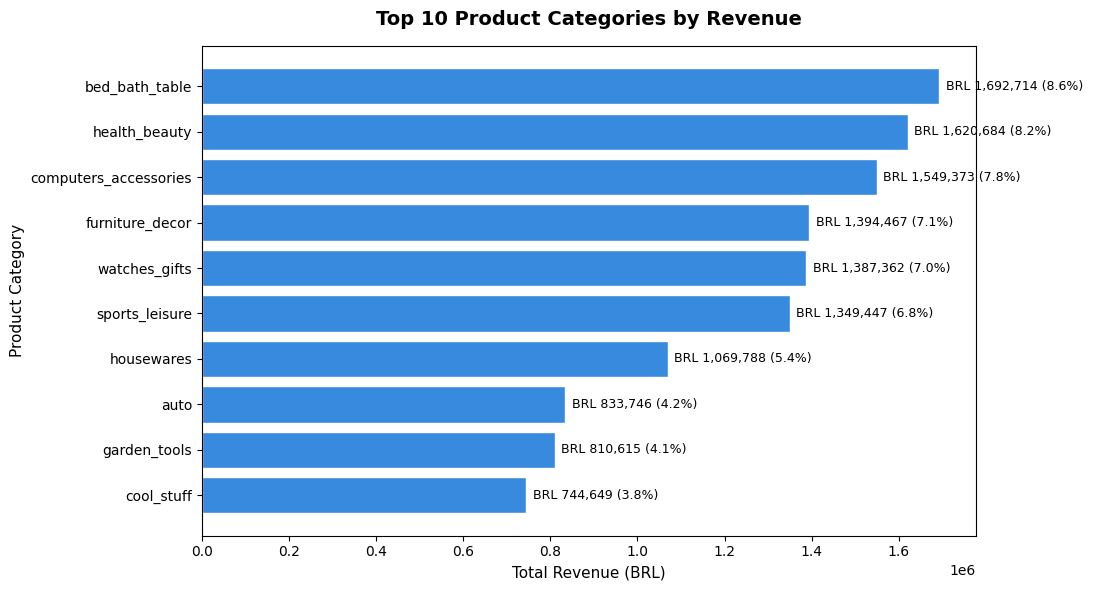

In [66]:
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    top10['product_category_name_english'][::-1],
    top10['total_revenue'][::-1],
    color='#378ADD', edgecolor='white'
)

# Label with BRL value + % share
for bar, (_, row) in zip(bars, top10[::-1].iterrows()):
    ax.text(bar.get_width() + 15000,
            bar.get_y() + bar.get_height()/2,
            f'BRL {row["total_revenue"]:,.0f} ({row["revenue_pct"]}%)',
            va='center', fontsize=9)

ax.set_title('Top 10 Product Categories by Revenue',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (BRL)', fontsize=11)
ax.set_ylabel('Product Category', fontsize=11)
plt.tight_layout()
plt.savefig('top10_category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

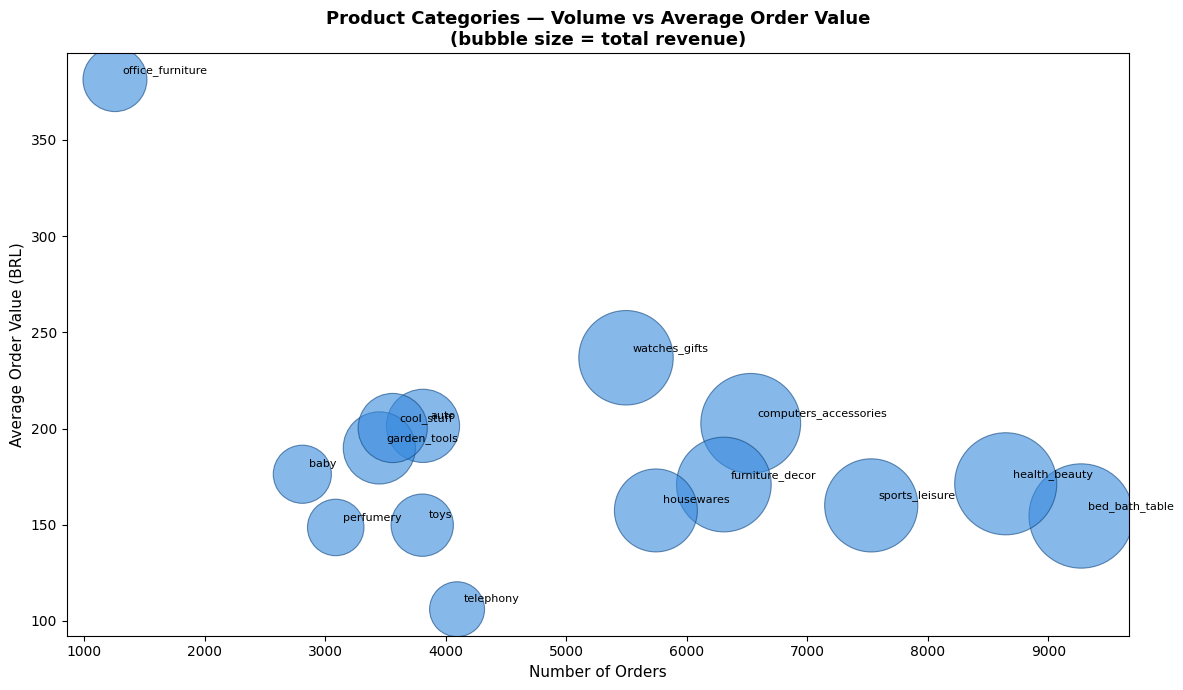

In [67]:
top15 = cat_df.sort_values('total_revenue', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    top15['order_count'],
    top15['avg_order_value'],
    s=top15['total_revenue'] / 300, # bubble size = revenue
    alpha=0.6,
    color='#378ADD',
    edgecolors='#0C447C',
    linewidth=0.8
)

# Label each bubble
for _, row in top15.iterrows():
    ax.annotate(
        row['product_category_name_english'],
        (row['order_count'], row['avg_order_value']),
        fontsize=8, ha='left',
        xytext=(5, 5), textcoords='offset points'
    )

ax.set_title('Product Categories — Volume vs Average Order Value\n(bubble size = total revenue)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Orders', fontsize=11)
ax.set_ylabel('Average Order Value (BRL)', fontsize=11)
plt.tight_layout()
plt.savefig('category_bubble.png', dpi=150, bbox_inches='tight')
plt.show()

## Delivery delay vs review score analysis 

In [68]:
review=pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv")
review

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [69]:
orders['order_delivered_customer_date']=pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date']=pd.to_datetime(orders['order_estimated_delivery_date'])

orders['Delivered in']=(orders['order_delivered_customer_date']-orders['order_estimated_delivery_date']).dt.days

In [70]:
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,Delivered in
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10.0
...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,-11.0
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,-2.0
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,-6.0
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,-21.0


In [71]:
print(review['review_score'].value_counts())
print("review",review.shape)
print("orders",orders.shape)
print("unique Order id in reviews",review['order_id'].nunique())
print("unique Order id in orders",orders['order_id'].nunique())

review_score
5    57328
4    19142
1    11424
3     8179
2     3151
Name: count, dtype: int64
review (99224, 7)
orders (99441, 9)
unique Order id in reviews 98673
unique Order id in orders 99441


In [72]:
review_scored=review.groupby('order_id')['review_score'].mean().reset_index()
review_scored.columns=['order_id','avg review score']
review_scored

,order_id,avg review score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0
...,...,...
98668,fffc94f6ce00a00581880bf54a75a037,5.0
98669,fffcd46ef2263f404302a634eb57f7eb,5.0
98670,fffce4705a9662cd70adb13d4a31832d,5.0
98671,fffe18544ffabc95dfada21779c9644f,5.0


In [73]:
delivery_review=orders.merge(review_scored,on='order_id',how='inner')
delivery_review=delivery_review[delivery_review['order_status']=='delivered']

In [74]:
delivery_review

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,Delivered in,avg review score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13.0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10.0,5.0
...,...,...,...,...,...,...,...,...,...,...
98668,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,-11.0,5.0
98669,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,-2.0,4.0
98670,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,-6.0,5.0
98671,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,-21.0,2.0


In [75]:
delivery_review=delivery_review.merge(master_df,on='order_id',how='inner')

In [76]:
delivery_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95831 entries, 0 to 95830
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       95831 non-null  object        
 1   customer_id_x                  95831 non-null  object        
 2   order_status_x                 95831 non-null  object        
 3   order_purchase_timestamp_x     95831 non-null  object        
 4   order_approved_at              95817 non-null  object        
 5   order_delivered_carrier_date   95829 non-null  object        
 6   order_delivered_customer_date  95823 non-null  datetime64[ns]
 7   order_estimated_delivery_date  95831 non-null  datetime64[ns]
 8   Delivered in                   95823 non-null  float64       
 9   avg review score               95831 non-null  float64       
 10  customer_id_y                  95831 non-null  object        
 11  customer_unique

In [77]:
delivery_review.describe()

,order_delivered_customer_date,order_estimated_delivery_date,Delivered in,avg review score,customer_zip_code_prefix,order_purchase_timestamp_y,payment_value
count,95823,95831,95823.000000,95831.000000,95831.000000,95831,95831.000000
mean,2018-01-14 15:25:08.232418304,2018-01-25 20:47:37.881061632,-11.913570,4.156219,35211.029729,2018-01-02 03:13:29.843536896,159.593775
min,2016-10-11 13:46:32,2016-10-27 00:00:00,-147.000000,1.000000,1003.000000,2016-10-03 09:44:50,9.590000
25%,2017-09-26 11:10:11.500000,2017-10-05 00:00:00,-17.000000,4.000000,11350.000000,2017-09-14 10:26:53.500000,61.840000
50%,2018-02-02 20:46:19,2018-02-16 00:00:00,-12.000000,5.000000,24435.000000,2018-01-20 23:48:24,105.280000
75%,2018-05-16 11:41:01.500000,2018-05-28 00:00:00,-7.000000,5.000000,59067.000000,2018-05-06 00:31:24,176.160000
max,2018-10-17 13:22:46,2018-10-25 00:00:00,188.000000,5.000000,99980.000000,2018-08-29 15:00:37,13664.080000
std,NaN,NaN,10.110605,1.283588,29857.820366,NaN,217.505618


In [78]:
delivery_review['delay days']=delivery_review['Delivered in']

In [79]:
delivery_review['review score']=delivery_review['avg review score'].round().astype(int)

In [80]:
bins = [-float('inf'), -15, -1, 7, 15, float('inf')]
labels = ['Very Early', 'Early', 'On Time', 'Late', 'Very Late']

delivery_review['delivery_bucket'] = pd.cut(
    delivery_review['delay days'],
    bins=bins,
    labels=labels
)

In [81]:
delivery_review.head()

,order_id,customer_id_x,order_status_x,order_purchase_timestamp_x,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,Delivered in,avg review score,...,customer_state,order_purchase_timestamp_y,order_status_y,payment_value,order_dayofweek,order_month,order_year,delay days,review score,delivery_bucket
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,4.0,...,SP,2017-10-02 10:56:33,delivered,38.71,Monday,2017-10,2017,-8.0,4,Early
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0,4.0,...,BA,2018-07-24 20:41:37,delivered,141.46,Tuesday,2018-07,2018,-6.0,4,Early
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0,5.0,...,GO,2018-08-08 08:38:49,delivered,179.12,Wednesday,2018-08,2018,-18.0,5,Very Early
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13.0,5.0,...,RN,2017-11-18 19:28:06,delivered,72.20,Saturday,2017-11,2017,-13.0,5,Early
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10.0,5.0,...,SP,2018-02-13 21:18:39,delivered,28.62,Tuesday,2018-02,2018,-10.0,5,Early


In [82]:
bucket_counts=delivery_review['delivery_bucket'].value_counts()

In [83]:
bucket_pct=(bucket_counts / len(delivery_review) * 100).round(1)

In [84]:
print(pd.DataFrame({'count': bucket_counts, 'pct': bucket_pct}))

                 count   pct
delivery_bucket             
Early            53392  55.7
Very Early       34771  36.3
On Time           4880   5.1
Late              1601   1.7
Very Late         1179   1.2


In [85]:
delivery_analysis = delivery_review.groupby('delivery_bucket', observed=True).agg(
    order_count=('order_id', 'count'),
    avg_review=('review score', 'mean'),
    pct_1star=('review score', lambda x: (x == 1).sum() / len(x) * 100),
    pct_5star=('review score', lambda x: (x == 5).sum() / len(x) * 100),
).reindex(labels).round(2)

# Add % of total orders
delivery_analysis['pct_of_orders'] = (
    delivery_analysis['order_count'] / delivery_analysis['order_count'].sum() * 100
).round(1)

print(delivery_analysis[['order_count', 'pct_of_orders',
                        'avg_review', 'pct_1star', 'pct_5star']])

                 order_count  pct_of_orders  avg_review  pct_1star  pct_5star
delivery_bucket                                                              
Very Early             34771           36.3        4.32       6.51      64.21
Early                  53392           55.7        4.28       6.58      61.19
On Time                 4880            5.1        3.06      32.66      30.86
Late                    1601            1.7        1.67      70.14       6.68
Very Late               1179            1.2        1.73      69.13       7.46


In [86]:
delivery_analysis.loc[['Late','Very Late']].sum()

order_count      2780.00
avg_review          3.40
pct_1star         139.27
pct_5star          14.14
pct_of_orders       2.90
dtype: float64

In [87]:
if 'payment_value' in delivery_review.columns:
    late_revenue = delivery_review[
        delivery_review['delivery_bucket'].isin(['Late', 'Very Late'])
    ]['payment_value'].sum()
    total_rev = delivery_review['payment_value'].sum()
    print(f"Revenue from late orders: BRL {late_revenue:,.0f}")
    print(f"% of total revenue: {late_revenue/total_rev*100:.1f}%")
    print(f"These customers avg review: {delivery_review[delivery_review['delivery_bucket'].isin(['Late','Very Late'])]['review score'].mean():.2f}")
else:
    print("payment_value not in delivery_df — merge master_df payment column first")

Revenue from late orders: BRL 508,558
% of total revenue: 3.3%
These customers avg review: 1.70


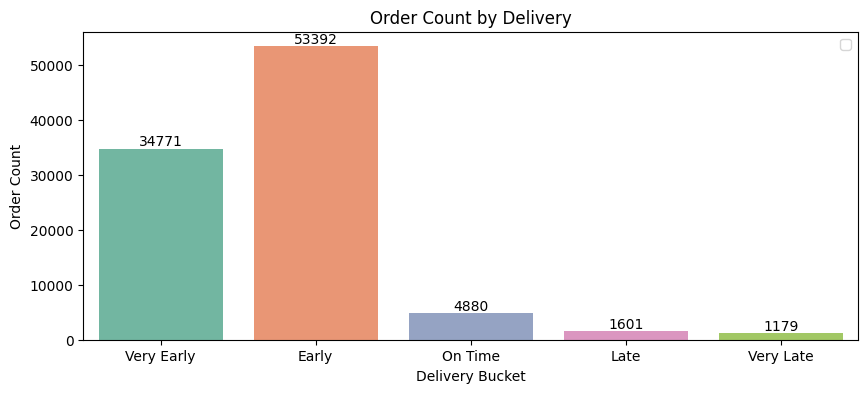

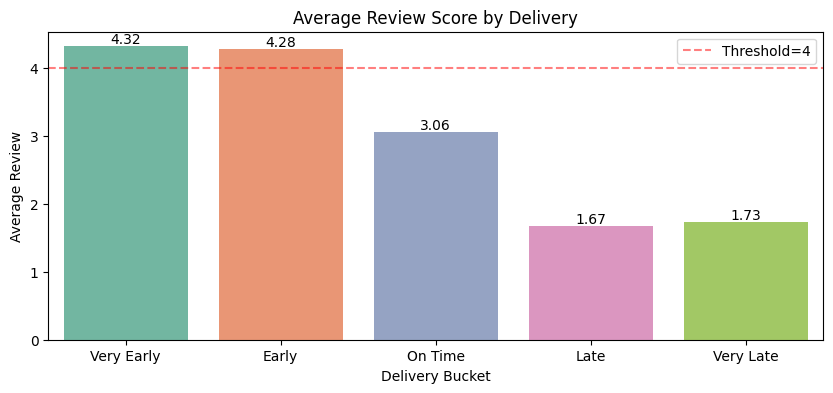

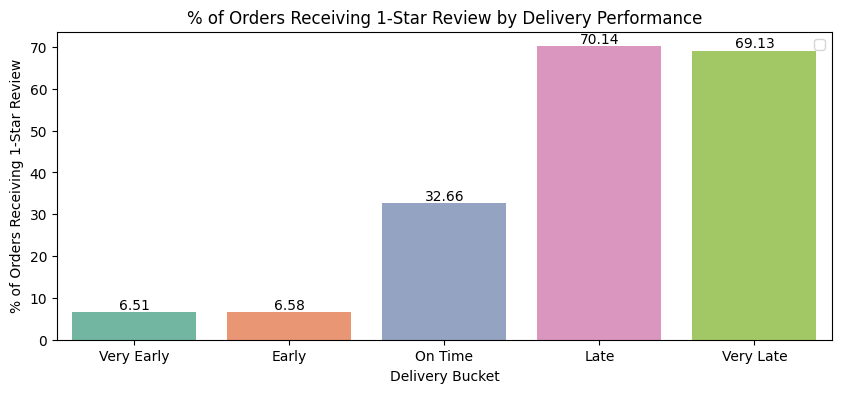

In [90]:
plt.figure(figsize=(10,4))
ax=sns.barplot(x=delivery_analysis.index,y=delivery_analysis['order_count'],palette='Set2')
for container in ax.containers:
    ax.bar_label(container)
plt.legend()
plt.xlabel("Delivery Bucket")
plt.ylabel("Order Count")
plt.title("Order Count by Delivery")
plt.show()

plt.figure(figsize=(10,4))
ax=sns.barplot(x=delivery_analysis.index,y=delivery_analysis['avg_review'],palette='Set2')
ax.axhline(y=4,color='red',linestyle='--',alpha=0.5, label='Threshold=4')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
plt.legend()
plt.xlabel("Delivery Bucket")
plt.ylabel("Average Review")
plt.title("Average Review Score by Delivery")
plt.show()

plt.figure(figsize=(10,4))
ax=sns.barplot(x=delivery_analysis.index,y=delivery_analysis['pct_1star'],palette='Set2')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
plt.legend()
plt.xlabel("Delivery Bucket")
plt.ylabel("% of Orders Receiving 1-Star Review")
plt.title("% of Orders Receiving 1-Star Review by Delivery Performance")
plt.show()